# RankNet on LETOR4
### Learning to Rank — Pointwise Neural Approach
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: RankNet — Deep Pointwise Scoring Network  
**Loss**: MSE loss  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **RankNet**, one of the foundational Learning-to-Rank (LTR) algorithms in Information Retrieval. The goal is to train a neural network that can predict the relevance label of a document for a given search query.

### What this notebook covers
| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset acquisition (LETOR4 / MQ2008) |
| 3    | Query-grouped PyTorch Dataset and DataLoader |
| 4–5  | Model architecture and pairwise loss function |
| 6–8 | Training, overfitting diagnosis, and dropout regularization |
| 9   | Test-set NDCG evaluation |
| 10   | 5-Fold Cross-Validation for statistical reliability |
| 11   | Ablation study across 4 architectures |

## Step 1 · Environment, Repository Structure & Dependency Setup
Install all required libraries, fix the random seed and verify GPU

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

PyTorch version : 2.11.0+cu128
NumPy version   : 2.0.2
Pandas version  : 2.2.2


In [2]:
# ── GPU / CPU selection ───────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Running on CPU — go to Runtime → Change runtime type → T4 GPU for faster training.")

print(f"\nActive device  : {DEVICE}")

CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.64 GB

Active device  : cuda


## Step 2 · Raw Dataset Acquisition & libsvm Format Inspection
Extract the LETOR4 zip and inspect the file structure.

In [3]:
import zipfile, os

zip_name = "MQ2008.zip"
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/")

print("\nExtraction complete. Contents:")


Extraction complete. Contents:


### Inspecting the Raw Data Format (`libsvm`)
The LETOR dataset uses the standard `libsvm` format, where each row represents a single document evaluated for a specific search query.

In [4]:
sample_file = "/content/MQ2008/Fold1/train.txt"
print(f"Inspecting: {sample_file}\n")
print("─" * 80)

with open(sample_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 4:
            break

print("─" * 80)
print("""
libsvm format breakdown:
  <relevance>  qid:<query_id>  1:<f1>  2:<f2>  ...  46:<f46>  #docid=...

  relevance → integer label  (0 = not relevant, 1 = relevant, 2 = highly relevant)
  qid       → query group id (all docs sharing a qid form one ranking list)
  1..46     → 46 pre-computed IR features (TF, IDF, BM25, PageRank, etc.)
  #docid    → trailing comment with document id (ignored during parsing)
""")

Inspecting: /content/MQ2008/Fold1/train.txt

────────────────────────────────────────────────────────────────────────────────
0 qid:10002 1:0.007477 2:0.000000 3:1.000000 4:0.000000 5:0.007470 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.471076 12:0.000000 13:1.000000 14:0.000000 15:0.477541 16:0.005120 17:0.000000 18:0.571429 19:0.000000 20:0.004806 21:0.768561 22:0.727734 23:0.716277 24:0.582061 25:0.000000 26:0.000000 27:0.000000 28:0.000000 29:0.780495 30:0.962382 31:0.999274 32:0.961524 33:0.000000 34:0.000000 35:0.000000 36:0.000000 37:0.797056 38:0.697327 39:0.721953 40:0.582568 41:0.000000 42:0.000000 43:0.000000 44:0.000000 45:0.000000 46:0.007042 #docid = GX008-86-4444840 inc = 1 prob = 0.086622
0 qid:10002 1:0.603738 2:0.000000 3:1.000000 4:0.000000 5:0.603175 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.000000 12:0.000000 13:0.122130 14:0.000000 15:0.000000 16:0.998377 17:0.375000 18:1.000000 19:0.000000 20:0.998128 21:0.000000 22:0.000000 23

## Step 3 · Query-Grouped Data Loading
RankNet evaluates pairs of documents for the exact same search query. Therefore, our PyTorch `Dataset` must yield data strictly grouped by `qid`. Since different queries have a different number of candidate documents, we will use a custom `collate_fn` to handle variable-length batches.

In [5]:
class LETORQueryDataset(Dataset):
    """
    Parses a LETOR libsvm file and groups documents by Query ID.
    Returns: (qid, features_tensor, labels_tensor) for a single query.
    """
    def __init__(self, filepath):
        self.filepath = filepath
        self.queries = [] # Will hold tuples of (qid, features, labels)
        self._load_and()

    def _load_and(self):
        current_qid = None
        current_features = []
        current_labels = []

        with open(self.filepath, 'r') as f:
            for line in tqdm(f, desc=f"Loading {os.path.basename(self.filepath)}"):
                parts = line.strip().split()
                if not parts:
                    continue

                label = int(parts[0])
                qid = parts[1].split(':')[1]
                features = [float(x.split(':')[1]) for x in parts[2:48]]

                # If we hit a new query, save the old one and start fresh
                if current_qid is not None and qid != current_qid:
                    # Only keep queries with >1 document (needed for pairwise comparison)
                    if len(current_labels) > 1:
                        self.queries.append((
                            current_qid,
                            torch.tensor(current_features, dtype=torch.float32),
                            torch.tensor(current_labels, dtype=torch.float32)
                        ))
                    current_features = []
                    current_labels = []

                current_qid = qid
                current_features.append(features)
                current_labels.append(label)

            # Don't forget to save the very last query in the file
            if current_qid is not None and len(current_labels) > 1:
                self.queries.append((
                    current_qid,
                    torch.tensor(current_features, dtype=torch.float32),
                    torch.tensor(current_labels, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, idx):
        return self.queries[idx]

def query_collate_fn(batch):
    """
    Handles batching of queries with varying numbers of documents.
    Returns lists of tensors instead of stacking them into a single rigid tensor.
    """
    qids = [item[0] for item in batch]
    features = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    return qids, features, labels

### Generalized DataLoader Function
To prepare for 5-Fold Cross-Validation, we will wrap our dataset initialization into a dynamic function. This allows us to pass a fold number (1-5) and instantly get the correct Train, Validation, and Test loaders back.

In [6]:
def get_dataloaders_for_fold(base_path="/content/MQ2008", fold_num=1, batch_size=4):
    """
    Dynamically loads the Train, Validation, and Test DataLoaders for a specific fold.
    """
    print(f"\nInitializing DataLoaders for Fold {fold_num}...")
    fold_dir = os.path.join(base_path, f"Fold{fold_num}")

    train_path = os.path.join(fold_dir, "train.txt")
    vali_path  = os.path.join(fold_dir, "vali.txt")
    test_path  = os.path.join(fold_dir, "test.txt")

    # Instantiate Datasets
    train_dataset = LETORQueryDataset(train_path)
    vali_dataset  = LETORQueryDataset(vali_path)
    test_dataset  = LETORQueryDataset(test_path)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=query_collate_fn)
    vali_loader  = DataLoader(vali_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)

    print(f"  Train queries : {len(train_dataset)}")
    print(f"  Vali queries  : {len(vali_dataset)}")
    print(f"  Test queries  : {len(test_dataset)}")

    return train_loader, vali_loader, test_loader

# ── Test the Generalized Function ──
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1)

# Inspect a single batch to verify it still works perfectly
sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print("\nSample Batch Inspection (Fold 1):")
print(f"Batch contains {len(sample_qids)} queries.")
print(f"Feature tensor shape (Query 1) : {sample_feats[0].shape} -> (num_docs, 46_features)")


Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 24174.53it/s]
Loading vali.txt: 2707it [00:00, 17215.97it/s]
Loading test.txt: 2874it [00:00, 13328.01it/s]

  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

Sample Batch Inspection (Fold 1):
Batch contains 4 queries.
Feature tensor shape (Query 1) : torch.Size([59, 46]) -> (num_docs, 46_features)


## Step 4 · Model Architecture (The Deep Pointwise Scorer)

We use a **Pointwise Scoring Network**, which means the network only looks at **one document at a time**.

### **Network Breakdown:**
* **Input Layer (46 nodes):** Receives the 46 Information Retrieval features for a single document.
* **Hidden Layers (64 nodes $\rightarrow$ 32 nodes):** A Multi-Layer Perceptron (MLP) that extracts complex, hidden patterns from the raw features.
* **Activations (ReLU):** Applied after each hidden layer to allow the network to learn non-linear relationships (e.g., recognizing that a feature might only be useful if another feature is also present).
* **Output Layer (1 node):** A single, continuous numerical score representing the document's predicted relevance.

In [7]:
import torch
import torch.nn as nn

class RankNet(nn.Module):
    def __init__(self, input_dim=46, hidden_dim=64, architecture_type='regularized'):
        super(RankNet, self).__init__()

        if architecture_type == 'linear':
            # Pure linear baseline: no activation functions, no hidden layers (46 -> 1)
            self.scorer = nn.Linear(input_dim, 1)

        elif architecture_type == 'baseline':
            # Our standard structure but with zero regularization (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'regularized':
            # Our standard structure protected by a 20% Dropout Rate (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'deep':
            # Over-parameterized Deep Network for Ablation (46 -> 128 -> 64 -> 32 -> 16 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 4, 1)
            )

    def forward(self, x):
        return self.scorer(x)

# Instantiate the model and move it to the GPU/CPU
model = RankNet(input_dim=46, hidden_dim=64).to(DEVICE)
print("RankNet Architecture Initialized:\n")
print(model)

# ─── Test the forward pass ───
sample_query_features = sample_feats[0].to(DEVICE)

# Run it through the untrained model
with torch.no_grad():
    sample_scores = model(sample_query_features)

print("\n" + "─"*50)
print(f"Forward Pass Diagnostics:")
print(f"Input features shape : {sample_query_features.shape}  -> (docs_in_query, 46)")
print(f"Output scores shape  : {sample_scores.shape}   -> (docs_in_query, 1)")
print("─"*50)

RankNet Architecture Initialized:

RankNet(
  (scorer): Sequential(
    (0): Linear(in_features=46, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

──────────────────────────────────────────────────
Forward Pass Diagnostics:
Input features shape : torch.Size([59, 46])  -> (docs_in_query, 46)
Output scores shape  : torch.Size([59, 1])   -> (docs_in_query, 1)
──────────────────────────────────────────────────


## Step 5 · Pointwise Loss Function(MSE)

In [13]:
import torch.nn.functional as F

def pointwise_loss(scores, labels):
    return F.mse_loss(scores.squeeze(), labels.float())

## Step 6 · Training Loop & Optimization Strategy

In [11]:
import torch.optim as optim
import copy

def train_ranknet(model, train_loader, val_loader, epochs=15, lr=0.001, device="cpu", verbose=True):
    """
    A generalized training engine for Pointwise approach.
    Processes any given model architecture and data split configuration.
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_loss = float('inf')
    best_model_weights = None
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        # ═════════════════ TRAINING PHASE ═════════════════
        model.train()
        total_train_loss = 0.0
        train_queries_count = 0

        for batch_qids, batch_feats, batch_labels in train_loader:
            optimizer.zero_grad()
            batch_loss = 0.0

            for i in range(len(batch_feats)):
                feats = batch_feats[i].to(device)
                labels = batch_labels[i].to(device)
                scores = model(feats)
                batch_loss += pointwise_loss(scores, labels)
                train_queries_count += 1

            batch_loss = batch_loss / len(batch_feats)
            batch_loss.backward()
            optimizer.step()
            total_train_loss += batch_loss.item() * len(batch_feats)

        avg_train_loss = total_train_loss / max(1, train_queries_count)
        train_loss_history.append(avg_train_loss)

        # ═════════════════ VALIDATION PHASE ═════════════════
        model.eval()
        total_val_loss = 0.0
        val_queries_count = 0

        with torch.no_grad():
            for batch_qids, batch_feats, batch_labels in val_loader:
                for i in range(len(batch_feats)):
                    feats = batch_feats[i].to(device)
                    labels = batch_labels[i].to(device)
                    scores = model(feats)
                    total_val_loss += pointwise_loss(scores, labels).item()
                    val_queries_count += 1

        avg_val_loss = total_val_loss / max(1, val_queries_count)
        val_loss_history.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | Train Loss: {avg_train_loss:.3f} | Val Loss: {avg_val_loss:.3f}")

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)

    return model, train_loss_history, val_loss_history

In [14]:
# 1. Instantiate the unregularized baseline model
baseline_model = RankNet(input_dim=46, architecture_type='baseline').to(DEVICE)

print("Starting Baseline Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, baseline_train_history, baseline_val_history = train_ranknet(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Baseline Training Complete!")

Starting Baseline Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train Loss: 0.322 | Val Loss: 0.303
Epoch 02/15 | Train Loss: 0.304 | Val Loss: 0.306
Epoch 03/15 | Train Loss: 0.302 | Val Loss: 0.301
Epoch 04/15 | Train Loss: 0.297 | Val Loss: 0.299
Epoch 05/15 | Train Loss: 0.295 | Val Loss: 0.299
Epoch 06/15 | Train Loss: 0.292 | Val Loss: 0.294
Epoch 07/15 | Train Loss: 0.290 | Val Loss: 0.296
Epoch 08/15 | Train Loss: 0.287 | Val Loss: 0.312
Epoch 09/15 | Train Loss: 0.289 | Val Loss: 0.301
Epoch 10/15 | Train Loss: 0.285 | Val Loss: 0.302
Epoch 11/15 | Train Loss: 0.286 | Val Loss: 0.299
Epoch 12/15 | Train Loss: 0.287 | Val Loss: 0.296
Epoch 13/15 | Train Loss: 0.280 | Val Loss: 0.294
Epoch 14/15 | Train Loss: 0.278 | Val Loss: 0.296
Epoch 15/15 | Train Loss: 0.278 | Val Loss: 0.301
═════════════════════════════════════════════════════════════════
Baseline Training Complete!


## Step 7 · Visualizing Training Diagnostics (Loss Curves)

To precisely evaluate model convergence and identify the exact onset of overfitting, we plot the historical trajectories of the Training and Validation losses recorded during Step 8.

### **Key Metrics to Observe:**
* **Convergence:** We look for the point where the training loss begins to plateau, indicating the optimization space is flattening out.
* **Divergence Point:** The exact epoch where the Validation Loss shifts from a downward trajectory to an upward curve. This point represents maximum generalization; running training loops past this threshold yields diminishing returns and degrades out-of-sample performance.

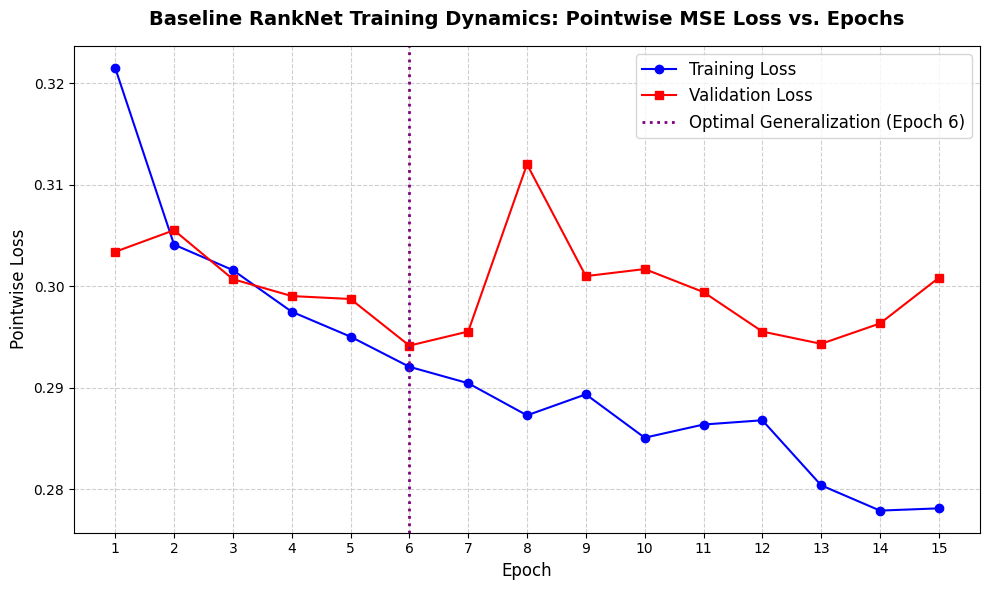

In [27]:
import matplotlib.pyplot as plt

def plot_training_dynamics(train_history, val_history, model_name="RankNet"):
    """
    Generates a standardized diagnostic line plot for training and validation losses.
    Automatically identifies and marks the optimal generalization epoch.
    """
    epochs_range = range(1, len(train_history) + 1)

    # Set up the plotting canvas
    plt.figure(figsize=(10, 6))

    # Plot historical trajectories
    plt.plot(epochs_range, train_history, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_history, label='Validation Loss', color='red', marker='s')

    # Add descriptive labels and titles dynamically
    plt.title(f'{model_name} Training Dynamics: Pointwise MSE Loss vs. Epochs', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Pointwise Loss', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Automatically pinpoint the absolute lowest validation loss step (Sweet Spot)
    min_val_epoch = val_history.index(min(val_history)) + 1

    # Draw the threshold line marking peak generalization
    plt.axvline(x=min_val_epoch, color='purple', linestyle=':', linewidth=2,
                label=f'Optimal Generalization (Epoch {min_val_epoch})')

    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_training_dynamics(baseline_train_history, baseline_val_history, model_name="Baseline RankNet")

### **Observation**:-
**Training loss** keeps steadily **decreasing** till epoch 15 (~0.278),but **Validation loss stops improving** after epoch 6 and becomes unstable

## Step 8 · Fixing Overfitting with Dropout Regularization

In [16]:
# 1. Instantiate the unregularized baseline model
regularized_model = RankNet(input_dim=46, architecture_type='regularized').to(DEVICE)

print("Starting Regularized Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, regularized_train_history, regularized_val_history = train_ranknet(
    model=regularized_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Regularized model Training Complete!")

Starting Regularized Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train Loss: 0.323 | Val Loss: 0.320
Epoch 02/15 | Train Loss: 0.313 | Val Loss: 0.303
Epoch 03/15 | Train Loss: 0.309 | Val Loss: 0.306
Epoch 04/15 | Train Loss: 0.308 | Val Loss: 0.300
Epoch 05/15 | Train Loss: 0.308 | Val Loss: 0.304
Epoch 06/15 | Train Loss: 0.305 | Val Loss: 0.300
Epoch 07/15 | Train Loss: 0.300 | Val Loss: 0.300
Epoch 08/15 | Train Loss: 0.300 | Val Loss: 0.312
Epoch 09/15 | Train Loss: 0.299 | Val Loss: 0.298
Epoch 10/15 | Train Loss: 0.298 | Val Loss: 0.299
Epoch 11/15 | Train Loss: 0.299 | Val Loss: 0.296
Epoch 12/15 | Train Loss: 0.297 | Val Loss: 0.296
Epoch 13/15 | Train Loss: 0.297 | Val Loss: 0.320
Epoch 14/15 | Train Loss: 0.293 | Val Loss: 0.295
Epoch 15/15 | Train Loss: 0.294 | Val Loss: 0.304
═════════════════════════════════════════════════════════════════
Regularized model Training Complete!


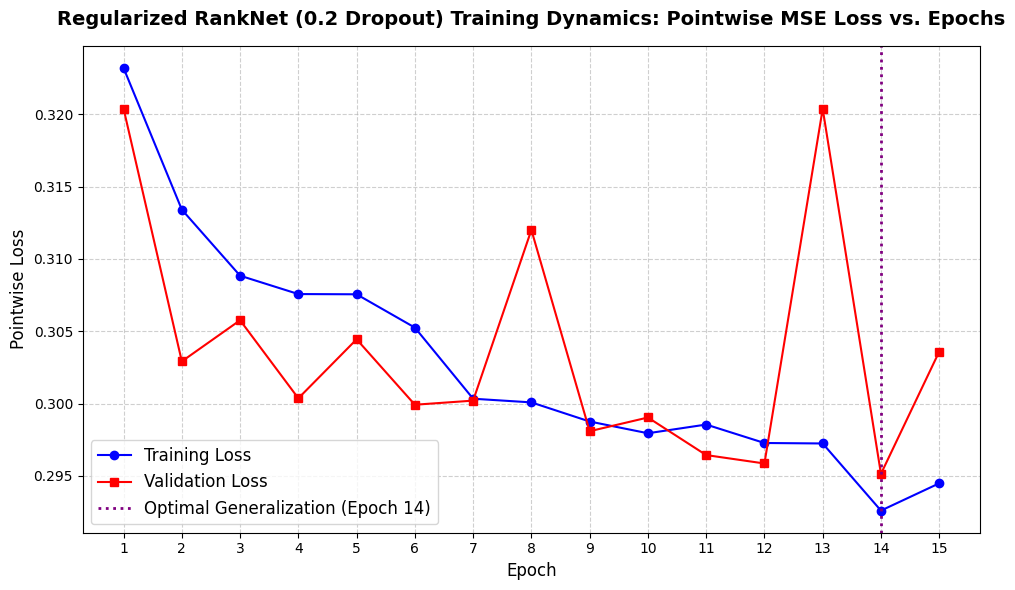

In [28]:
plot_training_dynamics(regularized_train_history, regularized_val_history, model_name="Regularized RankNet (0.2 Dropout)")

### Observation:-
- Baseline overfit at epoch 6, this model's optimal point is epoch 14
- From epoch 9, training and validation loss track very closely.
- Validation Loss Instability is still there

### why Regularization increased instability?
- Beacuse for every Epoch the network keeps on changing, sometimes we get a weaker network which cannot predict the output correctly.

## Step 9 · Test Set Evaluation (Baseline vs. Regularized NDCG)
## Evaluation Function

In [18]:
import numpy as np
import torch

def compute_dcg(relevance_scores, k):
    """
    Calculates Discounted Cumulative Gain (DCG) up to position k.
    """
    relevance_scores = np.asarray(relevance_scores,dtype=float)[:k]
    if relevance_scores.size == 0:
        return 0.0
    denominators = np.log2(np.arange(2, relevance_scores.size + 2))
    return np.sum((2 ** relevance_scores - 1) / denominators)


def evaluate_model_ndcg(model, data_loader, k_list=[1, 3, 5], device="cpu"):
    """
    Evaluates a RankNet model and returns Mean NDCG scores.
    Processes query groups individually to support variable document counts.
    """
    model.eval()

    qid_to_true_labels = {}
    qid_to_pred_scores = {}

    with torch.no_grad():
        for batch in data_loader:
            if isinstance(batch, dict):
                qids_list = batch['qids']
                feats_list = batch['feats']
                labels_list = batch['labels']
            else:
                qids_list, feats_list, labels_list = batch

            # Loop through each individual query group inside the mini-batch
            for qid, feats, labels in zip(qids_list, feats_list, labels_list):

                # Ensure the feature group is a proper PyTorch tensor
                if not isinstance(feats, torch.Tensor):
                    feats  = torch.tensor(feats, dtype=torch.float32)

                feats = feats.to(device)

                # Forward pass for this single query's documents
                scores = model(feats).squeeze().cpu().numpy()

                # Edge case: if a query has only 1 document, squeeze removes all dimensions
                if scores.ndim == 0:
                    scores = np.array([scores])

                # Clean up labels to a numpy array
                if isinstance(labels, torch.Tensor):
                    labels = labels.cpu().numpy()
                else:
                    labels = np.array(labels)

                # Extract a single scalar query ID for dictionary mapping
                if isinstance(qid, torch.Tensor):
                    qid_val = qid.cpu().numpy().flatten()[0]
                elif isinstance(qid, (list, np.ndarray)):
                    qid_val = np.array(qid).flatten()[0]
                else:
                    qid_val = qid

                # Initialize tracking buckets if this is a new query ID
                if qid_val not in qid_to_true_labels:
                    qid_to_true_labels[qid_val] = []
                    qid_to_pred_scores[qid_val] = []

                # Collect predictions and ground truths for this query profile
                qid_to_true_labels[qid_val].extend(labels)
                qid_to_pred_scores[qid_val].extend(scores)

    # ─── NDCG Core Metric Aggregation Loop ───
    ndcg_results = {k: [] for k in k_list}

    for qid in qid_to_true_labels.keys():
        true_rels = np.array(qid_to_true_labels[qid])
        pred_scores = np.array(qid_to_pred_scores[qid])

        if len(true_rels) < 2 or np.max(true_rels) == 0:
            continue

        predicted_sort_order = np.argsort(pred_scores)[::-1]
        model_ordered_labels = true_rels[predicted_sort_order]
        ideal_ordered_labels = sorted(true_rels, reverse=True)

        for k in k_list:
            idcg = compute_dcg(ideal_ordered_labels, k)
            dcg = compute_dcg(model_ordered_labels, k)

            if idcg > 0:
                ndcg_results[k].append(dcg / idcg)
            else:
                ndcg_results[k].append(0.0)

    mean_ndcg_scores = {
        k: np.mean(ndcg_results[k]) if ndcg_results[k] else 0.0 for k in k_list
    }

    return mean_ndcg_scores

## (Baseline vs. Regularized)

In [19]:
# 1. Run the test data through the baseline model
print("Evaluating Baseline Model on Test Set...")
baseline_test_ndcg = evaluate_model_ndcg(baseline_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 2. Run the test data through the regularized model
print("Evaluating Regularized Model on Test Set...")
regularized_test_ndcg = evaluate_model_ndcg(regularized_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 3. Render a clean, professional verification table
print("\n" + "═"*55)
print("        TEST SET NDCG PERFORMANCE COMPARISON")
print("═"*55)
print(f"{'Metric':<10} | {'Baseline (p=0.0)':<18} | {'Regularized (p=0.2)':<18}")
print("─"*55)
for k in [1, 3, 5, 10]:
    b_score = baseline_test_ndcg[k]
    r_score = regularized_test_ndcg[k]
    print(f"NDCG@{k:<2}   | {b_score:.4f}             | {r_score:.4f}")
print("═"*55)

Evaluating Baseline Model on Test Set...
Evaluating Regularized Model on Test Set...

═══════════════════════════════════════════════════════
        TEST SET NDCG PERFORMANCE COMPARISON
═══════════════════════════════════════════════════════
Metric     | Baseline (p=0.0)   | Regularized (p=0.2)
───────────────────────────────────────────────────────
NDCG@1    | 0.4825             | 0.4921
NDCG@3    | 0.5696             | 0.5712
NDCG@5    | 0.6454             | 0.6540
NDCG@10   | 0.7072             | 0.7088
═══════════════════════════════════════════════════════


## Step 11 · Test Set Evaluation: Pointwise vs Pairwise

### Pointwise vs Pairwise (Regularized Models)

| Metric   | Pairwise (RankNet) | Pointwise (MSE) | Difference |
|----------|--------------------|-----------------|------------|
| NDCG@1   | 0.5238             | 0.4921          | -0.0317    |
| NDCG@3   | 0.5798             | 0.5712          | -0.0086    |
| NDCG@5   | 0.6458             | 0.6540          | +0.0082    |
| NDCG@10  | 0.7116             | 0.7088          | -0.0028    |

### Key Takeaways
- Dropout helps in both approaches
- **Pairwise won over pointwise** - except at k=8, that might be a statistical noise, we can verify it in 5-Fold Cross Validation.

In [20]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 10 · Full 5-Fold Cross-Validation

In [21]:
import copy

K_LIST = [1, 3, 5, 10]

# Storage for results across all folds
fold_results = []

for fold_num in range(1, 6):
    print(f"\n{'═'*55}")
    print(f"  FOLD {fold_num} / 5")
    print(f"{'═'*55}")

    # ── 1. Fresh data loaders for this fold ──────────────────
    train_loader, vali_loader, test_loader = get_dataloaders_for_fold(
        fold_num=fold_num, batch_size=4
    )

    # ── 2. Fresh model for this fold (no weight leakage) ─────
    fold_model = RankNet(input_dim=46, hidden_dim=64,
                         architecture_type='regularized').to(DEVICE)

    # ── 3. Train ──────────────────────────────────────────────
    trained_model, train_hist, val_hist = train_ranknet(
        fold_model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # ── 4. Evaluate on test set ───────────────────────────────
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=K_LIST, device=DEVICE
    )

    # ── 5. Store results ──────────────────────────────────────
    fold_results.append({
        'fold'         : fold_num,
        'ndcg_scores'  : ndcg_scores,
        'train_history': train_hist,
        'val_history'  : val_hist,
    })

    print(f"\n  Test NDCG Results — Fold {fold_num}:")
    for k in K_LIST:
        print(f"    NDCG@{k:<3} : {ndcg_scores[k]:.4f}")


═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 32976.05it/s]
Loading vali.txt: 2707it [00:00, 17828.37it/s]
Loading test.txt: 2874it [00:00, 22765.90it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

  Test NDCG Results — Fold 1:
    NDCG@1   : 0.4825
    NDCG@3   : 0.5797
    NDCG@5   : 0.6435
    NDCG@10  : 0.7054

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 2...


Loading train.txt: 9404it [00:00, 44959.70it/s]
Loading vali.txt: 2874it [00:00, 39652.73it/s]
Loading test.txt: 2933it [00:00, 44984.93it/s]


  Train queries : 471
  Vali queries  : 156
  Test queries  : 157

  Test NDCG Results — Fold 2:
    NDCG@1   : 0.4889
    NDCG@3   : 0.5438
    NDCG@5   : 0.6096
    NDCG@10  : 0.6735

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 3...


...

  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 3:
    NDCG@1   : 0.4940
    NDCG@3   : 0.5330
    NDCG@5   : 0.5994
    NDCG@10  : 0.6755

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 4...


Loading train.txt: 8514it [00:00, 49641.98it/s]
Loading vali.txt: 3635it [00:00, 47800.02it/s]
Loading test.txt: 3062it [00:00, 45859.52it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 4:
    NDCG@1   : 0.5437
    NDCG@3   : 0.5802
    NDCG@5   : 0.6450
    NDCG@10  : 0.6976

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 5...


Loading train.txt: 9442it [00:00, 45890.11it/s]
Loading vali.txt: 3062it [00:00, 49160.40it/s]
Loading test.txt: 2707it [00:00, 44447.68it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 5:
    NDCG@1   : 0.4833
    NDCG@3   : 0.5532
    NDCG@5   : 0.6334
    NDCG@10  : 0.6927


In [22]:
print("\n" + "═"*55)
print("      5-FOLD CROSS-VALIDATION RESULTS (RankNet)")
print("═"*55)
print(f"{'Metric':<10}", end="")
for r in fold_results:
    print(f"  Fold{r['fold']}", end="")
print(f"  {'Mean':>7}  {'Std':>6}")
print("─"*55)

for k in K_LIST:
    scores = [r['ndcg_scores'][k] for r in fold_results]
    mean   = np.mean(scores)
    std    = np.std(scores)
    print(f"NDCG@{k:<5}", end="")
    for s in scores:
        print(f"  {s:.3f}", end="")
    print(f"  {mean:.3f}  {std:.3f}")

print("═"*55)


═══════════════════════════════════════════════════════
      5-FOLD CROSS-VALIDATION RESULTS (RankNet)
═══════════════════════════════════════════════════════
Metric      Fold1  Fold2  Fold3  Fold4  Fold5     Mean     Std
───────────────────────────────────────────────────────
NDCG@1      0.483  0.489  0.494  0.544  0.483  0.499  0.023
NDCG@3      0.580  0.544  0.533  0.580  0.553  0.558  0.019
NDCG@5      0.644  0.610  0.599  0.645  0.633  0.626  0.018
NDCG@10     0.705  0.673  0.675  0.698  0.693  0.689  0.012
═══════════════════════════════════════════════════════


### Pointwise vs Pairwise Cross-Validation (Mean ± Std)

| Metric  | Pairwise (RankNet)  | Pointwise (MSE)     |
|---------|---------------------|---------------------|
| NDCG@1  | 0.506 ± 0.022       | 0.499 ± 0.023       |
| NDCG@3  | 0.562 ± 0.024       | 0.558 ± 0.019       |
| NDCG@5  | 0.631 ± 0.016       | 0.626 ± 0.018       |
| NDCG@10 | 0.692 ± 0.018       | 0.689 ± 0.012       |

### Key Takeaways
- **close performance** — the Pairwise approach beats the pointwise approach but with a very small margin(+0.007).
- **Consistancy depends on ranking depth** - the std differs based on the ranking depth. For k=1,5 - Pairwise is more stable, whereas for k=3,10 - Pointwise is more stable.

## Step 11 · The Ablation Study (Deconstructing the Network)

In [24]:
# ── 1. Lock the Data Split to Fold 1 ──────────────────────
print("Loading Locked Data Split (Fold 1)...")
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1, batch_size=4)

ablation_results = {}
architectures = ['linear', 'baseline', 'regularized', 'deep']

print(f"\n{'═'*75}")
print(f"               ABLATION STUDY: TRAINING ARCHITECTURES")
print(f"{'═'*75}")

# ── 2. Train and Evaluate each architecture ───────────────
for arch in architectures:
    print(f"⚙️ Training '{arch}' model...")

    # Initialize the specific architecture
    model = RankNet(input_dim=46, hidden_dim=64, architecture_type=arch).to(DEVICE)

    # Train using our universal engine (suppressing epoch printouts for cleanliness)
    trained_model, train_hist, val_hist = train_ranknet(
        model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # Evaluate strictly on the Test Set
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE
    )

    # Store results (extracting the absolute lowest validation loss the model hit)
    ablation_results[arch] = {
        'ndcg': ndcg_scores,
        'val_loss': min(val_hist)
    }

# ── 3. Render the Final Ablation Leaderboard ──────────────
print("\n" + "═"*75)
print("        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)")
print("═"*75)
print(f"{'Architecture':<15} | {'Min Val Loss':<13} | {'NDCG@1':<8} | {'NDCG@3':<8} | {'NDCG@5':<8} | {'NDCG@10':<8}")
print("─"*75)
for arch in architectures:
    r = ablation_results[arch]
    print(f"{arch.capitalize():<15} | {r['val_loss']:<13.4f} | {r['ndcg'][1]:<8.4f} | {r['ndcg'][3]:<8.4f} | {r['ndcg'][5]:<8.4f} | | {r['ndcg'][10]:<8.4f}")
print("═"*75)

Loading Locked Data Split (Fold 1)...

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 26967.99it/s]
Loading vali.txt: 2707it [00:00, 15232.23it/s]
Loading test.txt: 2874it [00:00, 15104.99it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

═══════════════════════════════════════════════════════════════════════════
               ABLATION STUDY: TRAINING ARCHITECTURES
═══════════════════════════════════════════════════════════════════════════
⚙️ Training 'linear' model...
⚙️ Training 'baseline' model...
⚙️ Training 'regularized' model...
⚙️ Training 'deep' model...

═══════════════════════════════════════════════════════════════════════════
        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)
═══════════════════════════════════════════════════════════════════════════
Architecture    | Min Val Loss  | NDCG@1   | NDCG@3   | NDCG@5   | NDCG@10 
───────────────────────────────────────────────────────────────────────────
Linear          | 0.3053        | 0.5048   | 0.5884   | 0.6438   | | 0.7121  
Baseline        | 0.2914        | 0.4508   | 0.5580   | 0.6248   | | 0.6930  
Regularized     | 0.2929        | 0.5016   | 0.5840   | 0.6408   | | 0.7084

### Pointwise vs Pairwise Ablation (NDCG@10)

| Architecture | Pairwise (RankNet) | Pointwise (MSE) | Difference |
|--------------|--------------------|-----------------|------------|
| Linear       | 0.710             | 0.712          | +0.002    |
| Baseline     | 0.711             | 0.693          | -0.017    |
| Regularized  | 0.713             | 0.708          | -0.005    |
| Deep         | 0.697             | 0.699          | +0.002    |

### Key Takeaways
- Best models:-
    - Pairwise - Regularized(0.713)
    - Pointwise - Linear(0.712)
- Best Approach - **Depends on the model**
- The Best result from both approach are the same(0.01 is a negligible difference)

## Conclusion:-
Since the difference between the two approaches is very small, We can use pointwise approach for simplicity or Pairwise approach if we want the results as better as possible.